In [6]:
import os

zip_path = "/content/archive(4).zip"
print("Zip found:", os.path.exists(zip_path))
print("Zip size :", round(os.path.getsize(zip_path) / 1e6, 2), "MB")

Zip found: True
Zip size : 164.67 MB


In [7]:
import zipfile

zip_path = "/content/archive(4).zip"
extract_to = "/content/brain_tumor"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print("Extraction done!")

Extraction done!


In [8]:
import os

for root, dirs, files in os.walk("/content/brain_tumor"):
    level = root.replace("/content/brain_tumor", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:2]:
            print(f"{'  '*(level+1)}{f}")

brain_tumor/
  Training/
    pituitary/
    meningioma/
    glioma/
    notumor/
  Testing/
    pituitary/
    meningioma/
    glioma/
    notumor/


In [9]:
import os

DATA_DIR = "/content/brain_tumor"

for split in ["Training", "Testing"]:
    print(f"\n{split}:")
    split_path = os.path.join(DATA_DIR, split)
    total = 0
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        count = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  {cls:20s} → {count} images")
        total += count
    print(f"  {'TOTAL':20s} → {total} images")


Training:
  glioma               → 1400 images
  meningioma           → 1400 images
  notumor              → 1400 images
  pituitary            → 1400 images
  TOTAL                → 5600 images

Testing:
  glioma               → 400 images
  meningioma           → 400 images
  notumor              → 400 images
  pituitary            → 400 images
  TOTAL                → 1600 images


In [10]:
import os, random, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt

# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.10.0+cu128


In [11]:
# ── paths & data ─────────────────────────────────────────────
DATA_DIR         = "/content/brain_tumor"
NUM_CLASSES      = 4
IMG_SIZE         = 224
LABELED_FRAC     = 0.10          # 10% labeled data

# ── training ─────────────────────────────────────────────────
BATCH_LABELED    = 16
BATCH_UNLABELED  = 32
EPOCHS           = 50
LR               = 1e-4

# ── FlexMatch specific ───────────────────────────────────────
GLOBAL_THRESHOLD = 0.95
THRESHOLD_WARMUP = True
UNSUP_WEIGHT     = 1.0

print("Config set!")
print(f"Labeled samples   : {int(5600 * LABELED_FRAC)} (10%)")
print(f"Unlabeled samples : {int(5600 * (1-LABELED_FRAC))} (90%)")
print(f"Test samples      : 1600")

Config set!
Labeled samples   : 560 (10%)
Unlabeled samples : 5040 (90%)
Test samples      : 1600


In [12]:
# Weak augmentation → generates reliable pseudo-labels
weak_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Strong augmentation → what model must classify correctly
strong_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15),
                            scale=(0.85, 1.15)),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Validation — no augmentation, just resize & normalize
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Augmentations ready!")

Augmentations ready!


In [13]:
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import train_test_split
from PIL import Image

class BrainTumorDataset(Dataset):
    """Standard labeled dataset."""
    def __init__(self, root, split="Training", transform=None):
        self.transform   = transform
        self.samples     = []
        self.class_names = sorted(os.listdir(os.path.join(root, split)))
        for idx, cls in enumerate(self.class_names):
            folder = os.path.join(root, split, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(folder, fname), idx))

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label


class UnlabeledDualViewDataset(Dataset):
    """Returns (weak_view, strong_view) for each unlabeled image."""
    def __init__(self, root, split="Training"):
        self.paths = []
        for cls in os.listdir(os.path.join(root, split)):
            folder = os.path.join(root, split, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.paths.append(os.path.join(folder, fname))

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return weak_transform(img), strong_transform(img)


# ── build 10% labeled / 90% unlabeled split ──────────────────
full_train  = BrainTumorDataset(DATA_DIR, split="Training", transform=strong_transform)
all_idx     = list(range(len(full_train)))
all_labels  = [full_train.samples[i][1] for i in all_idx]

labeled_idx, _ = train_test_split(
    all_idx, train_size=LABELED_FRAC,
    stratify=all_labels, random_state=SEED
)

labeled_dataset   = Subset(full_train, labeled_idx)
unlabeled_dataset = UnlabeledDualViewDataset(DATA_DIR, split="Training")
val_dataset       = BrainTumorDataset(DATA_DIR, split="Testing", transform=val_transform)

labeled_loader   = DataLoader(labeled_dataset,   batch_size=BATCH_LABELED,
                               shuffle=True,  drop_last=True,  num_workers=2, pin_memory=True)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_UNLABELED,
                               shuffle=True,  drop_last=True,  num_workers=2, pin_memory=True)
val_loader       = DataLoader(val_dataset,       batch_size=32,
                               shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = full_train.class_names
print(f"Classes          : {CLASS_NAMES}")
print(f"Labeled samples  : {len(labeled_dataset)}")
print(f"Unlabeled samples: {len(unlabeled_dataset)}")
print(f"Test samples     : {len(val_dataset)}")

Classes          : ['glioma', 'meningioma', 'notumor', 'pituitary']
Labeled samples  : 560
Unlabeled samples: 5600
Test samples     : 1600


In [14]:
class FlexMatchThresholdBank:
    """
    FixMatch → one fixed threshold for all classes (e.g. 0.95)
    FlexMatch → separate dynamic threshold per class
      - Easy classes (high confidence) → threshold rises toward GLOBAL_THRESHOLD
      - Hard classes (low confidence)  → threshold stays low, accepts more pseudo-labels
    """
    def __init__(self, num_classes, global_threshold=0.95, warmup=True):
        self.num_classes      = num_classes
        self.global_threshold = global_threshold
        self.warmup           = warmup
        self.class_counts     = torch.zeros(num_classes)

    def update(self, probs):
        """probs: (B, C) softmax probabilities from weak-augmented unlabeled batch."""
        pseudo_labels = probs.argmax(dim=1)
        max_probs     = probs.max(dim=1).values
        mask_above    = max_probs > 0.5

        for c in range(self.num_classes):
            class_mask = (pseudo_labels == c) & mask_above
            self.class_counts[c] += class_mask.sum().item()

    def get_thresholds(self):
        """Returns per-class thresholds as a tensor of shape (num_classes,)."""
        if self.class_counts.max() == 0:
            return torch.full((self.num_classes,),
                              0.5 if self.warmup else self.global_threshold)

        beta = self.class_counts / (self.class_counts.max() + 1e-9)

        if self.warmup:
            thresholds = self.global_threshold * (beta / (2.0 - beta))
        else:
            thresholds = self.global_threshold * beta

        return thresholds

    def summary(self):
        thresholds = self.get_thresholds()
        print("\nFlexMatch per-class thresholds:")
        for c in range(self.num_classes):
            print(f"  {CLASS_NAMES[c]:15s} → threshold = {thresholds[c]:.4f} "
                  f"| count = {int(self.class_counts[c])}")

# initialise
threshold_bank = FlexMatchThresholdBank(
    num_classes=NUM_CLASSES,
    global_threshold=GLOBAL_THRESHOLD,
    warmup=THRESHOLD_WARMUP
)
print("FlexMatch threshold bank ready!")

FlexMatch threshold bank ready!


In [15]:
from torchvision import models

def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model     = build_resnet50(NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model             : ResNet50")
print(f"Trainable params  : {total_params:,}")
print(f"Optimizer         : Adam (lr={LR})")
print(f"Scheduler         : CosineAnnealingLR (T_max={EPOCHS})")
print(f"Model on device   : {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]


Model             : ResNet50
Trainable params  : 23,516,228
Optimizer         : Adam (lr=0.0001)
Scheduler         : CosineAnnealingLR (T_max=50)
Model on device   : cuda:0


In [16]:
def train_one_epoch(model, labeled_loader, unlabeled_loader,
                    optimizer, threshold_bank, epoch):
    model.train()
    total_sup    = 0.0
    total_unsup  = 0.0
    total_masked = 0
    total_unlab  = 0
    correct = 0; total = 0

    unlabeled_iter = iter(unlabeled_loader)

    for imgs_l, labels in labeled_loader:
        imgs_l = imgs_l.to(DEVICE)
        labels = labels.to(DEVICE)

        try:
            imgs_weak, imgs_strong = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            imgs_weak, imgs_strong = next(unlabeled_iter)

        imgs_weak   = imgs_weak.to(DEVICE)
        imgs_strong = imgs_strong.to(DEVICE)

        # supervised loss on labeled data
        logits_l = model(imgs_l)
        sup_loss = F.cross_entropy(logits_l, labels)

        # pseudo-label generation from weak view
        with torch.no_grad():
            probs_weak    = torch.softmax(model(imgs_weak), dim=1)
            pseudo_labels = probs_weak.argmax(dim=1)
            max_probs     = probs_weak.max(dim=1).values

        # update FlexMatch threshold bank
        threshold_bank.update(probs_weak.cpu())

        # per-class dynamic thresholds
        thresholds        = threshold_bank.get_thresholds().to(DEVICE)
        sample_thresholds = thresholds[pseudo_labels]
        mask              = (max_probs >= sample_thresholds).float()

        # unsupervised loss on strong view
        logits_strong         = model(imgs_strong)
        unsup_loss_per_sample = F.cross_entropy(logits_strong, pseudo_labels, reduction='none')
        unsup_loss            = (unsup_loss_per_sample * mask).mean()

        # total loss
        loss = sup_loss + UNSUP_WEIGHT * unsup_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_sup    += sup_loss.item()
        total_unsup  += unsup_loss.item()
        total_masked += mask.sum().item()
        total_unlab  += mask.size(0)
        preds    = logits_l.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    n          = len(labeled_loader)
    mask_ratio = 100.0 * total_masked / max(total_unlab, 1)
    return total_sup/n, total_unsup/n, 100.*correct/total, mask_ratio


def evaluate(model, loader):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return 100. * correct / total

print("Training functions ready!")

Training functions ready!


In [17]:
best_acc = 0.0
history  = {
    "sup_loss": [], "unsup_loss": [],
    "train_acc": [], "val_acc": [], "mask_ratio": []
}

print(f"{'Ep':>3} | {'SupLoss':>8} | {'UnsupLoss':>9} | {'TrainAcc':>8} | {'ValAcc':>7} | {'Mask%':>6}")
print("-" * 58)

for epoch in range(1, EPOCHS + 1):
    sup_l, unsup_l, train_acc, mask_ratio = train_one_epoch(
        model, labeled_loader, unlabeled_loader,
        optimizer, threshold_bank, epoch
    )
    val_acc = evaluate(model, val_loader)
    scheduler.step()

    history["sup_loss"].append(sup_l)
    history["unsup_loss"].append(unsup_l)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["mask_ratio"].append(mask_ratio)

    print(f"{epoch:>3} | {sup_l:>8.4f} | {unsup_l:>9.4f} | "
          f"{train_acc:>7.2f}% | {val_acc:>6.2f}% | {mask_ratio:>5.1f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_flexmatch_resnet50.pth")
        print(f"  *** Best model saved: {best_acc:.2f}% ***")

    if epoch % 10 == 0:
        threshold_bank.summary()

print(f"\nBest FlexMatch Accuracy: {best_acc:.2f}%")

 Ep |  SupLoss | UnsupLoss | TrainAcc |  ValAcc |  Mask%
----------------------------------------------------------
  1 |   0.7233 |    0.1858 |   73.57% |  82.75% |  54.2%
  *** Best model saved: 82.75% ***
  2 |   0.4833 |    0.0709 |   84.82% |  86.88% |  69.6%
  *** Best model saved: 86.88% ***
  3 |   0.3678 |    0.0688 |   86.79% |  84.94% |  72.5%
  4 |   0.3017 |    0.0738 |   89.11% |  89.38% |  77.6%
  *** Best model saved: 89.38% ***
  5 |   0.2605 |    0.0570 |   90.00% |  86.75% |  78.8%
  6 |   0.2500 |    0.0416 |   91.07% |  89.75% |  82.3%
  *** Best model saved: 89.75% ***
  7 |   0.2229 |    0.0579 |   91.25% |  90.88% |  82.1%
  *** Best model saved: 90.88% ***
  8 |   0.2106 |    0.0360 |   92.68% |  91.69% |  83.2%
  *** Best model saved: 91.69% ***
  9 |   0.1763 |    0.0403 |   93.75% |  89.81% |  83.9%
 10 |   0.2008 |    0.0471 |   92.86% |  87.00% |  84.6%

FlexMatch per-class thresholds:
  glioma          → threshold = 0.8881 | count = 2667
  meningioma     

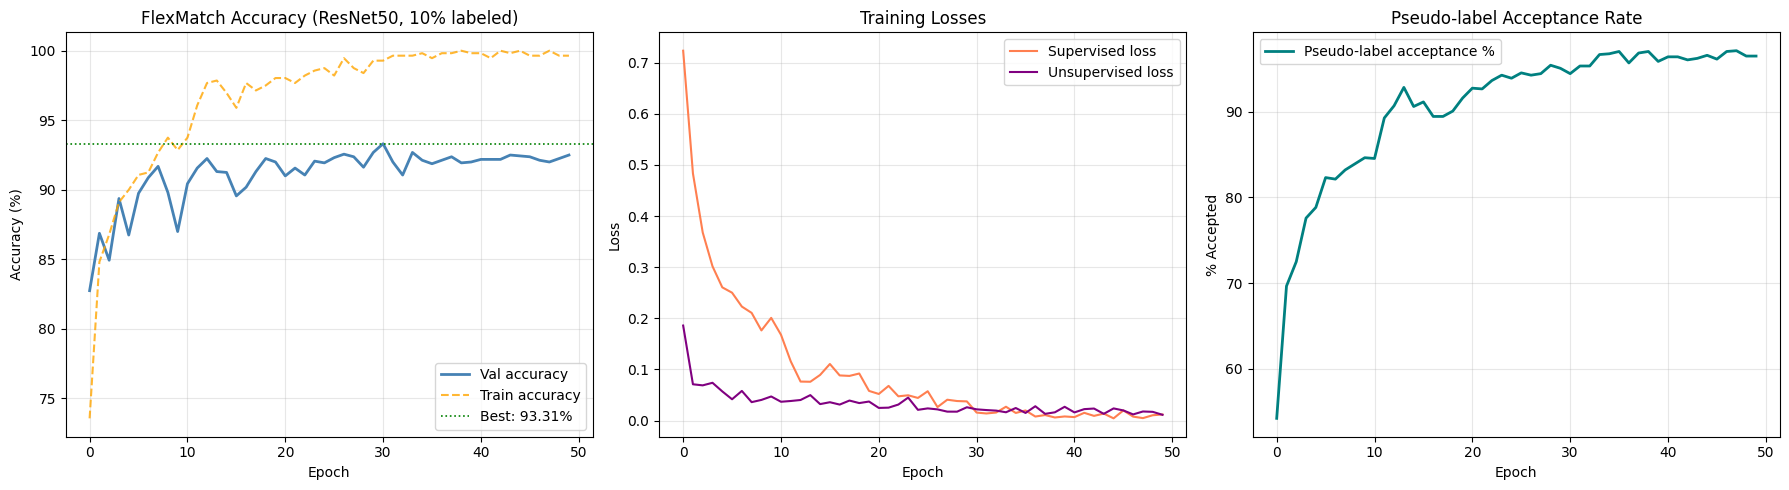


Final per-class thresholds:

FlexMatch per-class thresholds:
  glioma          → threshold = 0.8983 | count = 13740
  meningioma      → threshold = 0.8826 | count = 13615
  notumor         → threshold = 0.9231 | count = 13932
  pituitary       → threshold = 0.9500 | count = 14135

Best FlexMatch Accuracy: 93.31%


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# accuracy
axes[0].plot(history["val_acc"],   label="Val accuracy",   linewidth=2, color="steelblue")
axes[0].plot(history["train_acc"], label="Train accuracy", linewidth=1.5,
             linestyle="--", color="orange", alpha=0.8)
axes[0].axhline(y=best_acc, color="green", linestyle=":", linewidth=1.2,
                label=f"Best: {best_acc:.2f}%")
axes[0].set_title("FlexMatch Accuracy (ResNet50, 10% labeled)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# losses
axes[1].plot(history["sup_loss"],   label="Supervised loss",   color="coral")
axes[1].plot(history["unsup_loss"], label="Unsupervised loss", color="purple")
axes[1].set_title("Training Losses")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

# mask ratio
axes[2].plot(history["mask_ratio"], label="Pseudo-label acceptance %",
             color="teal", linewidth=2)
axes[2].set_title("Pseudo-label Acceptance Rate")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("% Accepted")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("flexmatch_results.png", dpi=150)
plt.show()

# final threshold summary
print("\nFinal per-class thresholds:")
threshold_bank.summary()
print(f"\nBest FlexMatch Accuracy: {best_acc:.2f}%")

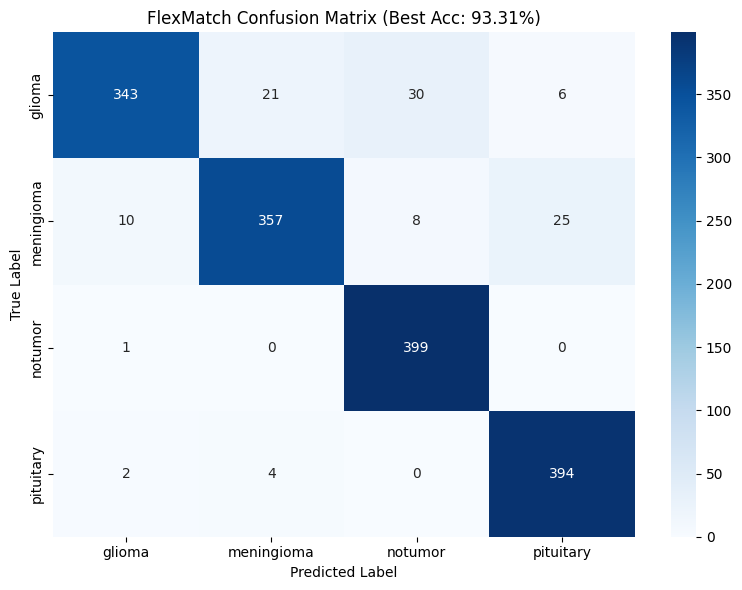


Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.86      0.91       400
  meningioma       0.93      0.89      0.91       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.93      0.98      0.96       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.load_state_dict(torch.load("best_flexmatch_resnet50.pth"))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title(f"FlexMatch Confusion Matrix (Best Acc: {best_acc:.2f}%)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("flexmatch_confusion_matrix.png", dpi=150)
plt.show()

# per class report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))